<a href="https://colab.research.google.com/github/joaohppenha/govspendertest/blob/main/Agrupamento_segmentacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentação de Perfis de Consumo com K-Means



Este notebook tem como objetivo agrupar os CPFs da base de dados de gastos públicos por similaridade de comportamento de consumo. Para isso, utilizaremos o algoritmo de aprendizado de máquina não supervisionado **K-Means**.

### O que será feito neste notebook:
1. **Importação e Autenticação:** Conexão segura com o GitHub utilizando um token armazenado nos *Secrets* do Google Colab para baixar a base em formato `.parquet`.
2. **Seleção de Variáveis:** Filtragem das colunas de comportamento geral de gastos:
   - `VOLUME_TOTAL_LOG_SCALED`: Volume total gasto (normalizado).
   - `TICKET_MEDIO_LOG_SCALED`: Valor médio por transação (normalizado).
3. **Treinamento do Modelo (K-Means):** O algoritmo vai rodar em toda a base e aproximar os CPFs que possuem números parecidos nessas duas métricas, dividindo-os em 3 grupos (clusters).
4. **Padronização Lógica das Etiquetas:** Reorganização automática dos grupos para garantir uma interpretação intuitiva:
   - **`0`**: Grupo que gasta pouco
   - **`1`**: Grupo de gastos moderados
   - **`2`**: Grupo que gasta mais (gasta muito)
5. **Resultado Prático:** Criação da nova coluna `cluster_kmeans` na base de dados, categorizando cada linha, seguida de um gráfico de dispersão para visualização dos perfis formados.

**Instalação e Importação de Bibliotecas**

In [ ]:
# Instalação das bibliotecas necessárias para leitura de arquivos parquet e modelagem
!pip install -q pyarrow fastparquet requests scikit-learn seaborn matplotlib

import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from google.colab import userdata

print("Bibliotecas importadas com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.3 MB/s eta 0:00:00
Bibliotecas importadas com sucesso!


**Download da Base**

Linhas e colunas da camada Gold

In [4]:
import io
import requests
import pandas as pd
from google.colab import userdata

# 1. Configurando a autenticação (opcional/caso use Secrets)
try:
    github_token = userdata.get('Githubtolken')
except Exception as e:
    github_token = None

url = "https://github.com/joaohppenha/govspendertest/raw/refs/heads/main/gold/camada_gold.parquet"

headers = {}
if github_token:
    headers["Authorization"] = f"token {github_token}"

# 2. Baixando e carregando o arquivo Parquet diretamente para o DataFrame
response = requests.get(url, headers=headers)
if response.status_code == 200:
    df = pd.read_parquet(io.BytesIO(response.content))
    print("Base carregada com sucesso do GitHub!")
else:
    raise Exception(f"Erro ao baixar o arquivo. Status code: {response.status_code}")

# 3. Exibindo as primeiras linhas
print(df.head())

Base carregada com sucesso do GitHub!
                                   HASH_CPF_PORTADOR  QTD_TRANSACOES  \
0  000edd7142e0a18d234c19e52222ad8fa27230eab85cca...               4   
1  0044817ad2e2f83f9f53d70c07731412d0c4880b13d7aa...               7   
2  0048938b883fdd9eb27e4021a1e0e9e87d389933382be1...               1   
3  009d7a3b99570625c93525120c3905601245c6142d5268...               4   
4  00b8a6cc4636fded01e21620f7e2a04c427d472a0db3f3...               9   

   VOLUME_TOTAL  TICKET_MEDIO  VOLATILIDADE_STD  PCT_SAQUES  PCT_COMPRAS  \
0        116.51     29.127500         27.437647         0.0          1.0   
1        608.40     86.914286         94.219432         0.0          1.0   
2        499.00    499.000000          0.000000         0.0          1.0   
3       1568.54    392.135000        276.111327         0.0          1.0   
4      12991.14   1443.460000        964.362100         0.0          1.0   

   PCT_SIGILO  QTD_TRANSACOES_LOG  VOLUME_TOTAL_LOG  TICKET_MEDIO_LOG  \

In [ ]:
# Resgatando o token dos Secrets do Colab de forma segura
try:
    github_token = userdata.get('Githubtolken')
except Exception as e:
    github_token = None
    print("Aviso: Token não encontrado nos Secrets. Tentando acesso público...")

# URL no formato raw fornecida
url = "https://github.com/joaohppenha/govspendertest/raw/refs/heads/main/gold/camada_gold.parquet"

headers = {}
if github_token:
    headers["Authorization"] = f"token {github_token}"

print("Baixando a base de dados do GitHub...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    # Leitura do arquivo parquet diretamente em memória
    df = pd.read_parquet(io.BytesIO(response.content))
    print(f"Sucesso! Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")
else:
    raise Exception(f"Erro ao baixar o arquivo. Status code: {response.status_code}. Verifique se o secret 'GITHUB_TOKEN' está configurado corretamente.")

# Exibindo as primeiras linhas para validação
display(df[['HASH_CPF_PORTADOR', 'VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].head())

Baixando a base de dados do GitHub...
Sucesso! Base carregada com 2810 linhas e 19 colunas.


,HASH_CPF_PORTADOR,VOLUME_TOTAL_LOG_SCALED,TICKET_MEDIO_LOG_SCALED
0,000edd7142e0a18d234c19e52222ad8fa27230eab85cca...,-1.458633,-2.201331
1,0044817ad2e2f83f9f53d70c07731412d0c4880b13d7aa...,-0.597081,-1.356829
2,0048938b883fdd9eb27e4021a1e0e9e87d389933382be1...,-0.700652,0.013905
3,009d7a3b99570625c93525120c3905601245c6142d5268...,-0.101876,-0.175712
4,00b8a6cc4636fded01e21620f7e2a04c427d472a0db3f3...,1.004440,0.850489


**Treinamento do K-Means e Classificação dos Perfis**

In [8]:
from sklearn.cluster import KMeans
# 1. Selecionando as colunas para o comportamento geral de gastos
X = df[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].values

# 2. Executando o treinamento do K-Means (definindo 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_temp'] = kmeans.fit_predict(X)

# 3. Padronizando as etiquetas (Labels) de forma lógica com base no volume médio
# 0 = Gasta pouco, 1 = Gastos moderados, 2 = Gasta muito
cluster_ordem = df.groupby('cluster_temp')['VOLUME_TOTAL_LOG_SCALED'].mean().sort_values().index
mapeamento = {cluster_ordem[0]: 0, cluster_ordem[1]: 1, cluster_ordem[2]: 2}

df['cluster_kmeans'] = df['cluster_temp'].map(mapeamento)
df.drop(columns=['cluster_temp'], inplace=True)

# 4. Exibindo a distribuição final dos CPFs por perfil
print("Distribuição dos CPFs por Perfil de Consumo:")
print(df['cluster_kmeans'].value_counts().sort_index())

Distribuição dos CPFs por Perfil de Consumo:
cluster_kmeans
0     423
1    1377
2    1010
Name: count, dtype: int64


**Visualização Gráfica dos Grupos**

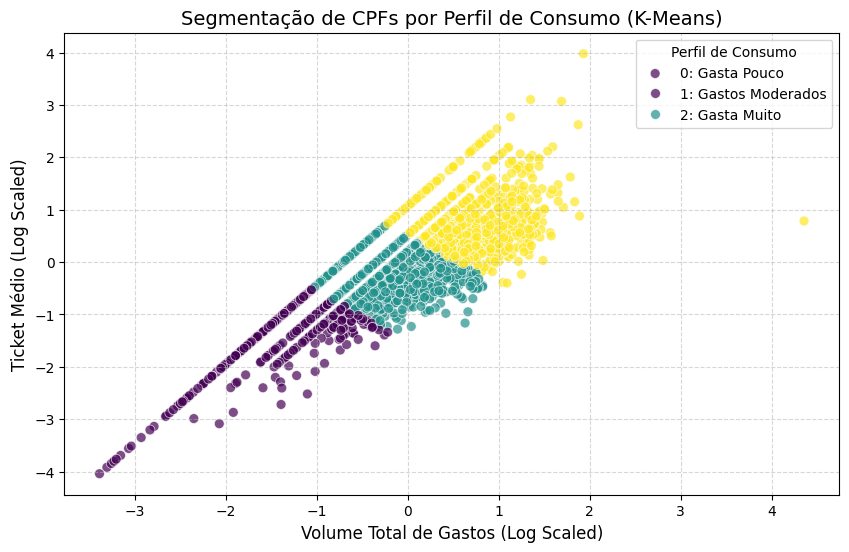

In [ ]:
# Plotando o gráfico de dispersão dos perfis de consumo
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG_SCALED',
    y='TICKET_MEDIO_LOG_SCALED',
    hue='cluster_kmeans',
    palette='viridis',
    alpha=0.7,
    s=50
)

plt.title('Segmentação de CPFs por Perfil de Consumo (K-Means)', fontsize=14)
plt.xlabel('Volume Total de Gastos (Log Scaled)', fontsize=12)
plt.ylabel('Ticket Médio (Log Scaled)', fontsize=12)
plt.legend(title='Perfil de Consumo', labels=['0: Gasta Pouco', '1: Gastos Moderados', '2: Gasta Muito'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Explicação das Métricas**

### Avaliação da Qualidade dos Grupos (Métricas)


Para garantir que os CPFs foram bem separados, podemos calcular métricas de validação de clusters:
1. **Inércia (Within-Cluster Sum of Squares):** Mede o quão compactos são os clusters (quanto menor, mais unidos os pontos são dentro do mesmo grupo).
2. **Coeficiente de Silhueta (Silhouette Score):** Mede o quão bem separados os grupos estão uns dos outros. Varia de `-1` a `1`:
   - Próximo de `1`: Os grupos estão bem definidos e separados.
   - Próximo de `0`: Há sobreposição entre os grupos.
   - Negativo: Os pontos podem estar no grupo errado.

---



Utilizamos o Coeficiente de Silhueta para medir a separação dos clusters e a Inércia para garantir a compactação interna de cada grupo de gasto. K-Means agrupou os CPFs geometricamente com base no volume total e no ticket médio normalizados, e depois ordenamos as etiquetas de 0 a 2 em ordem crescente de consumo.



In [ ]:
from sklearn.metrics import silhouette_score

# 1. Inércia (WSS) - quanto menor, mais coeso é o agrupamento
inercia = kmeans.inertia_
print(f"Inércia do Modelo (Compactação): {inercia:.2f}")

# 2. Coeficiente de Silhueta - avalia a separação entre os 3 perfis
score_silhueta = silhouette_score(X, df['cluster_kmeans'])
print(f"Coeficiente de Silhueta Médio: {score_silhueta:.4f}")

# Estatísticas descritivas de cada grupo para justificar as métricas na prática
print("\nMédia de Gastos e Ticket por Perfil:")
resumo_clusters = df.groupby('cluster_kmeans')[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].agg(['mean', 'count'])
display(resumo_clusters)

Inércia do Modelo (Compactação): 1145.64
Coeficiente de Silhueta Médio: 0.4126

Média de Gastos e Ticket por Perfil:


VOLUME_TOTAL_LOG_SCALED       TICKET_MEDIO_LOG_SCALED      
                                  mean count                    mean count
cluster_kmeans                                                            
0                            -1.313684   423               -1.375282   423
1                            -0.182750  1377               -0.202661  1377
2                             0.649219  1010                0.751986  1010

## Isolation Forest

**Seleção de features preparadas**

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Alimentando o modelo

features_modelos = [
    'QTD_TRANSACOES_LOG_SCALED',
    'VOLUME_TOTAL_LOG_SCALED',
    'TICKET_MEDIO_LOG',
    'VOLATILIDADE_STD_LOG',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

# Conferindo se tem valor nulo nas variáveis de treino
df[features_modelos] = df[features_modelos].fillna(0)

**Instanciamento e treinamento do Isolation Forest**

In [11]:
# Orienta o modelo a marcar o top 1% mais anômalo

modelo = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# O modelo avalia cada portador e retorna 1 ou -1

df['score_anomalia'] = modelo.fit_predict(df[features_modelos])

# Tradução de -1 para True (é anomalia) para o filtro

df['alerta_fraude'] = df['score_anomalia'] == -1

print(df['alerta_fraude'].value_counts())

alerta_fraude
False    2781
True       29
Name: count, dtype: int64


**Visualização do comportamento atípico**

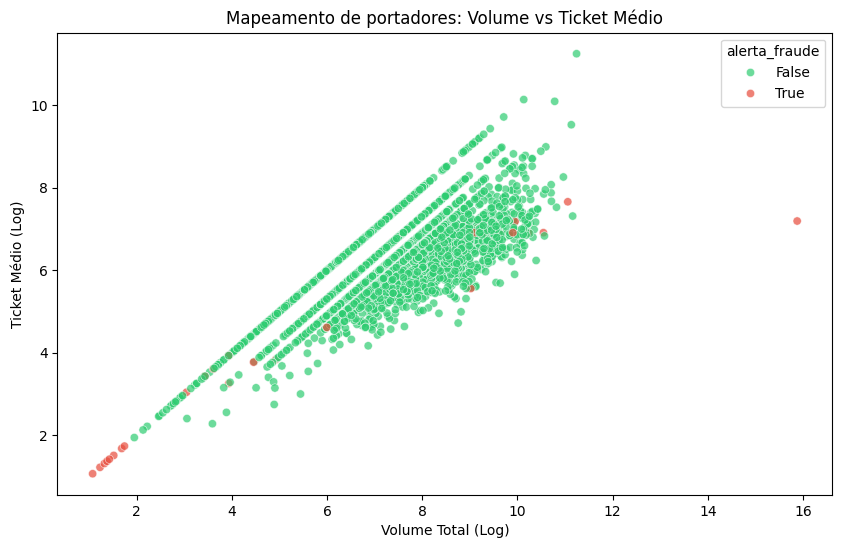

In [12]:
plt.figure(figsize=(10, 6))

# Plotando o volume total vs ticket médio

sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG',
    y='TICKET_MEDIO_LOG',
    hue='alerta_fraude',
    palette={False: '#2ecc71', True: '#e74c3c'},
    alpha=0.7

)

plt.title('Mapeamento de portadores: Volume vs Ticket Médio')
plt.xlabel('Volume Total (Log)')
plt.ylabel('Ticket Médio (Log)')
plt.show()

**Auditoria dos casos isolados**

In [13]:
# Filtrando apenas os portadores anômalos e trazendo as colunas para leitura

portadores_suspeitos = df[df['alerta_fraude']].sort_values(by='VOLUME_TOTAL', ascending=False)

colunas_auditoria = [
    'HASH_CPF_PORTADOR',
    'QTD_TRANSACOES',
    'VOLUME_TOTAL',
    'TICKET_MEDIO',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

display(portadores_suspeitos[colunas_auditoria].head(10))

,HASH_CPF_PORTADOR,QTD_TRANSACOES,VOLUME_TOTAL,TICKET_MEDIO,PCT_SAQUES,PCT_SIGILO
1717,HASH_NAO_INFORMADO,5934,7871500.64,1326.508365,0.000000,1.0
2059,bef51bb3efe382350b888e70397392e1040d088003a39b...,30,63429.90,2114.330000,0.200000,0.0
884,53bc0c4ee5c5ecbfe809625dc146832f5a3634901b6c85...,38,38000.00,1000.000000,1.000000,0.0
1533,8e47d2a453d5026bd08c24e2130cb5cb570a557d1eccc8...,28,27800.00,992.857143,1.000000,0.0
631,3e1e5868c7a92ad903d93ceaa056466cbee13c3e45f7ef...,16,20950.76,1309.422500,1.000000,0.0
2596,eda59412be9be5539c447294b36ed2be91a25a48e9e4c2...,20,20000.00,1000.000000,1.000000,0.0
993,5d6b50db49b6d6b513c43df0b659472d19e8e24da91eb8...,15,14990.00,999.333333,1.000000,0.0
1080,6495178ea1fc669f9d927c1ed8b52c0e7626dfea3b6856...,11,10999.27,999.933636,0.909091,0.0
1196,703c688c7a2b4fcb3272336c3a53ea82f6ece388e2642c...,8,9790.78,1223.847500,1.000000,0.0
1953,b6340de8120b206b17afe757d357c35f86c5d082aeb369...,9,9000.00,1000.000000,1.000000,0.0


## Cruzamento de Dados

In [21]:
## Cruzamento de Dados: K-Means + Isolation Forest

# 1. Cruzando o perfil de maior risco do K-Means (Cluster 2: Gasta Muito) com o alerta de fraude do Isolation Forest
df['transacao_suspeita'] = ((df['cluster_kmeans'] == 2) & (df['alerta_fraude'] == True)).astype(int)

# 2. Resumo quantitativo do cruzamento
total_geral = len(df)
total_suspeitos = df['transacao_suspeita'].sum()
percentual = (total_suspeitos / total_geral) * 100

print(f"Total de registros na base: {total_geral}")
print(f"Total de CPFs Altamente Suspeitos (Cluster 2 + Anomalia IF): {total_suspeitos} ({percentual:.2f}% da base)")

# 3. Exibindo a auditoria cruzada dos principais casos ordenados pelo maior volume de gastos
colunas_cruzamento = [
    'HASH_CPF_PORTADOR',
    'cluster_kmeans',
    'QTD_TRANSACOES',
    'VOLUME_TOTAL',
    'TICKET_MEDIO',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

print("\nTop 10 Portadores Mais Suspeitos (Foco de Auditoria):")
display(df[df['transacao_suspeita'] == 1][colunas_cruzamento].sort_values(by='VOLUME_TOTAL', ascending=False).head(10))

Total de registros na base: 2810
Total de CPFs Altamente Suspeitos (Cluster 2 + Anomalia IF): 11 (0.39% da base)

Top 10 Portadores Mais Suspeitos (Foco de Auditoria):


,HASH_CPF_PORTADOR,cluster_kmeans,QTD_TRANSACOES,VOLUME_TOTAL,TICKET_MEDIO,PCT_SAQUES,PCT_SIGILO
1717,HASH_NAO_INFORMADO,2,5934,7871500.64,1326.508365,0.000000,1.0
2059,bef51bb3efe382350b888e70397392e1040d088003a39b...,2,30,63429.90,2114.330000,0.200000,0.0
884,53bc0c4ee5c5ecbfe809625dc146832f5a3634901b6c85...,2,38,38000.00,1000.000000,1.000000,0.0
1533,8e47d2a453d5026bd08c24e2130cb5cb570a557d1eccc8...,2,28,27800.00,992.857143,1.000000,0.0
631,3e1e5868c7a92ad903d93ceaa056466cbee13c3e45f7ef...,2,16,20950.76,1309.422500,1.000000,0.0
2596,eda59412be9be5539c447294b36ed2be91a25a48e9e4c2...,2,20,20000.00,1000.000000,1.000000,0.0
993,5d6b50db49b6d6b513c43df0b659472d19e8e24da91eb8...,2,15,14990.00,999.333333,1.000000,0.0
1080,6495178ea1fc669f9d927c1ed8b52c0e7626dfea3b6856...,2,11,10999.27,999.933636,0.909091,0.0
1196,703c688c7a2b4fcb3272336c3a53ea82f6ece388e2642c...,2,8,9790.78,1223.847500,1.000000,0.0
1953,b6340de8120b206b17afe757d357c35f86c5d082aeb369...,2,9,9000.00,1000.000000,1.000000,0.0


##Relatório em PDF

In [23]:
!pip install -q reportlab
import os
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

# 1. Configurando o arquivo PDF
pdf_filename = "relatorio_transacoes_suspeitas.pdf"
doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=letter,
    rightMargin=36, leftMargin=36,
    topMargin=36, bottomMargin=36
)

story = []
styles = getSampleStyleSheet()

# Paleta de Cores Corporativa
PRIMARY_COLOR = colors.HexColor("#1A365D")
SECONDARY_COLOR = colors.HexColor("#2B6CB0")
TEXT_DARK = colors.HexColor("#2D3748")
BG_LIGHT = colors.HexColor("#F7FAFC")

# Estilos de Texto
title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=18, leading=22, textColor=PRIMARY_COLOR, spaceAfter=4)
subtitle_style = ParagraphStyle('DocSubtitle', parent=styles['Normal'], fontName='Helvetica', fontSize=10, leading=14, textColor=colors.HexColor("#718096"), spaceAfter=15)
section_heading = ParagraphStyle('SectionHeading', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=12, leading=16, textColor=PRIMARY_COLOR, spaceBefore=10, spaceAfter=6)
body_style = ParagraphStyle('BodyTextCustom', parent=styles['Normal'], fontName='Helvetica', fontSize=9, leading=13, textColor=TEXT_DARK)
table_header_style = ParagraphStyle('TableHeader', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=8, leading=10, textColor=colors.white, alignment=1)
table_cell_style = ParagraphStyle('TableCell', parent=styles['Normal'], fontName='Helvetica', fontSize=8, leading=10, textColor=TEXT_DARK, alignment=1)

# 2. Construção do Conteúdo do Relatório
story.append(Paragraph("Relatório de Auditoria: Transações e Portadores Suspeitos", title_style))
story.append(Paragraph("Cruzamento de Modelos: K-Means (Perfil de Alto Gasto) + Isolation Forest (Anomalias Comportamentais)", subtitle_style))
story.append(HRFlowable(width="100%", thickness=1.5, color=PRIMARY_COLOR, spaceAfter=12))

story.append(Paragraph("Resumo Executivo da Auditoria", section_heading))
resumo_texto = (
    "Este relatório consolida os resultados do cruzamento analítico entre a segmentação de perfis de consumo (K-Means) "
    "e a detecção estatística de desvios (Isolation Forest). O foco da auditoria recai sobre os portadores classificados simultaneamente "
    "no grupo de maior expressão financeira (Cluster 2 - Gasta Muito) e identificados como comportamentos anômalos pelo modelo de isolamento. "
    "Abaixo encontram-se os principais indicadores e a listagem dos casos prioritários para verificação de conformidade."
)
story.append(Paragraph(resumo_texto, body_style))
story.append(Spacer(1, 10))

story.append(Paragraph("Tabela: Principais Portadores Prioritários para Investigação", section_heading))

# 3. Filtrando os dados reais do seu DataFrame para preencher a tabela
# Certifique-se de que a coluna 'transacao_suspeita' já foi criada no passo anterior
try:
    df_suspeitos = df[df['transacao_suspeita'] == 1].sort_values(by='VOLUME_TOTAL', ascending=False).head(10)
except:
    df_suspeitos = df.head(5) # Fallback caso o filtro não exista no escopo atual

# Montando as linhas da tabela dinamicamente com base no seu DataFrame
headers = ["Hash CPF Portador", "Qtd Trans.", "Volume Total", "Ticket Médio", "% Saques", "% Sigilo"]
table_data = [[Paragraph(h, table_header_style) for h in headers]]

for _, row in df_suspeitos.iterrows():
    # Tratando valores de forma segura
    cpf_hash = str(row.get('HASH_CPF_PORTADOR', 'N/D'))
    cpf_formatado = f"{cpf_hash[:8]}..." if len(cpf_hash) > 8 else cpf_hash

    row_cells = [
        Paragraph(cpf_formatado, table_cell_style),
        Paragraph(str(row.get('QTD_TRANSACOES', 0)), table_cell_style),
        Paragraph(f"R$ {row.get('VOLUME_TOTAL', 0):,.2f}", table_cell_style),
        Paragraph(f"R$ {row.get('TICKET_MEDIO', 0):,.2f}", table_cell_style),
        Paragraph(f"{row.get('PCT_SAQUES', 0)*100:.1f}%" if row.get('PCT_SAQUES', 0) <= 1 else f"{row.get('PCT_SAQUES', 0):.1f}%", table_cell_style),
        Paragraph(f"{row.get('PCT_SIGILO', 0)*100:.1f}%" if row.get('PCT_SIGILO', 0) <= 1 else f"{row.get('PCT_SIGILO', 0):.1f}%", table_cell_style),
    ]
    table_data.append(row_cells)

col_widths = [140, 60, 90, 80, 65, 65]
t = Table(table_data, colWidths=col_widths)
t.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), PRIMARY_COLOR),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 5),
    ('TOPPADDING', (0, 0), (-1, 0), 5),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, BG_LIGHT]),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor("#E2E8F0")),
]))

story.append(t)
story.append(Spacer(1, 15))

story.append(Paragraph("Recomendações e Próximos Passos", section_heading))
rec_texto = (
    "1. <b>Validação Documental:</b> Solicitar os processos de despesa vinculados aos maiores volumes totais.<br/>"
    "2. <b>Cruzamento de Sigilo:</b> Avaliar a justificativa legal para transações que apresentam percentual elevado de sigilo.<br/>"
    "3. <b>Auditoria de Saques:</b> Verificar conformidade nos casos onde o índice de saques em espécie supera o limite de alerta interno."
)
story.append(Paragraph(rec_texto, body_style))

# Compilando o PDF
doc.build(story)
print(f"Relatório PDF gerado com sucesso: {pdf_filename}")

# 4. Código opcional para disparar o download automático no navegador do Colab
from google.colab import files
files.download(pdf_filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.2 MB/s eta 0:00:00
Relatório PDF gerado com sucesso: relatorio_transacoes_suspeitas.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exporta para o Github

In [24]:
import base64
import requests
from google.colab import userdata

# 1. Recuperando o token dos Secrets do Google Colab
try:
    github_token = userdata.get('Githubtolken')
except Exception as e:
    raise Exception("Erro ao recuperar o secret 'Githubtolken'. Verifique se ele está configurado corretamente no Colab.")

# 2. Configurações do Repositório e Caminho do Arquivo
owner = "joaohppenha"
repo = "govspendertest"
branch = "main"
caminho_pasta = "Documentação"
nome_arquivo = "relatorio_transacoes_suspeitas.pdf"
caminho_completo_repo = f"{caminho_pasta}/{nome_arquivo}"

# Certifique-se de que o PDF já foi gerado na etapa anterior no ambiente local do Colab
local_pdf_path = "relatorio_transacoes_suspeitas.pdf"

with open(local_pdf_path, "rb") as pdf_file:
    pdf_bytes = pdf_file.read()

# Codificando o conteúdo do PDF em Base64 (exigido pela API do GitHub)
pdf_base64 = base64.b64encode(pdf_bytes).decode("utf-8")

# 3. Verificando se o arquivo já existe no repositório (para obter o 'sha' caso seja uma atualização/commit de sobrescrita)
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{caminho_completo_repo}"
headers = {
    "Authorization": f"token {github_token}",
    "Accept": "application/vnd.github.v3+json"
}

response_get = requests.get(api_url, headers=headers)
sha = None
if response_get.status_code == 200:
    sha = response_get.json().get("sha")

# 4. Preparando o payload para envio via API do GitHub
payload = {
    "message": "Add/Update relatório PDF de transações suspeitas via Colab",
    "content": pdf_base64,
    "branch": branch
}
if sha:
    payload["sha"] = sha  # Necessário caso o arquivo já exista para atualizar a versão

# 5. Realizando o commit e push automáticos via API
response_put = requests.put(api_url, headers=headers, json=payload)

if response_put.status_code in [200, 201]:
    print(f"Sucesso! Relatório enviado com sucesso para a pasta '{caminho_pasta}' no GitHub.")
    print(f"URL de acesso: https://github.com/{owner}/{repo}/blob/{branch}/{caminho_completo_repo}")
else:
    print(f"Erro ao enviar para o GitHub. Status code: {response_put.status_code}")
    print(response_put.json())

Sucesso! Relatório enviado com sucesso para a pasta 'Documentação' no GitHub.
URL de acesso: https://github.com/joaohppenha/govspendertest/blob/main/Documentação/relatorio_transacoes_suspeitas.pdf
